# Capstone C: Customer Segmentation

This project groups mall customers into distinct segments and
translates them into a business recommendation a marketing team could
act on — a practical, business-oriented workflow.

Dataset: Mall Customer Segmentation, from Kaggle (200 customers, 5
features: CustomerID, Gender, Age, Annual Income, Spending Score).

Workflow: data preparation -> feature selection -> standardization ->
dimensionality reduction (if it adds value) -> cluster number
selection (elbow, silhouette) -> final clustering -> segment
profiling and naming -> business recommendation -> limitations

There are no true labels here, so validation relies on internal
checks (elbow, silhouette, stability) and on whether the segments are
distinct and useful enough to treat differently.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('Mall_Customers.csv')

print(df.shape)
print(df.columns.to_list())
print(df.isnull().sum())

(200, 5)
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [50]:
print(df['Genre'].unique())
print(df['Genre'].value_counts())

['Male' 'Female']
Genre
Female    112
Male       88
Name: count, dtype: int64


Note: the column is labeled `Genre` in the source file, but contains
`Male`/`Female` values. This is a naming quirk in the original dataset,
not a typo introduced here.

## Feature Selection

`CustomerID` is excluded, it's just a row identifier with no
information. `Genre` (Male/Female) is also excluded from the
clustering itself, since including a categorical feature alongside
numeric ones adds distance-metric complexity without a clear reason
to think it separates customers meaningfully on its own. Instead,
`Genre` is checked afterward, against the clusters the numeric
features produce, so if a segment does skew by gender, that's a
genuine finding from the data rather than an assumption built into
the method.

Clustering uses: Age, Annual Income (k$), Spending Score (1-100).

In [51]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]
print(X.describe())

              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.000000               73.000000
max     70.000000          137.000000               99.000000


In [52]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]


In [53]:
print(X.corr())

                             Age  Annual Income (k$)  Spending Score (1-100)
Age                     1.000000           -0.012398               -0.327227
Annual Income (k$)     -0.012398            1.000000                0.009903
Spending Score (1-100) -0.327227            0.009903                1.000000


## Dimensionality Reduction: Why PCA Is Not Used Here

PCA is most valuable when a dataset has many features carrying
overlapping information, so that several of them can be compressed
into a handful of components with little loss. That is not the case
here.

With only three features, the pairwise correlations are all weak
(|r| ≤ 0.33, confirmed directly rather than assumed):

| | Age | Income | Spending Score |
|---|---|---|---|
| Age | 1.00 | -0.01 | -0.33 |
| Income | -0.01 | 1.00 | 0.01 |
| Spending Score | -0.33 | 0.01 | 1.00 |

Each feature carries largely independent information. Clustering
proceeds directly on the three standardized features.

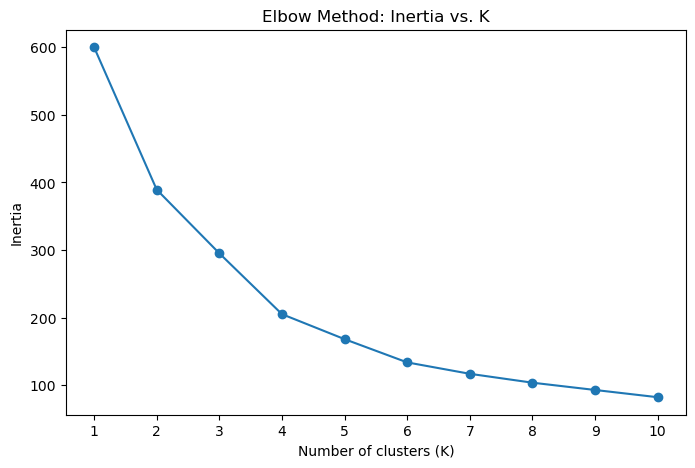

In [54]:
inertia =[]
k_values = range(1, 11)

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method: Inertia vs. K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.show()

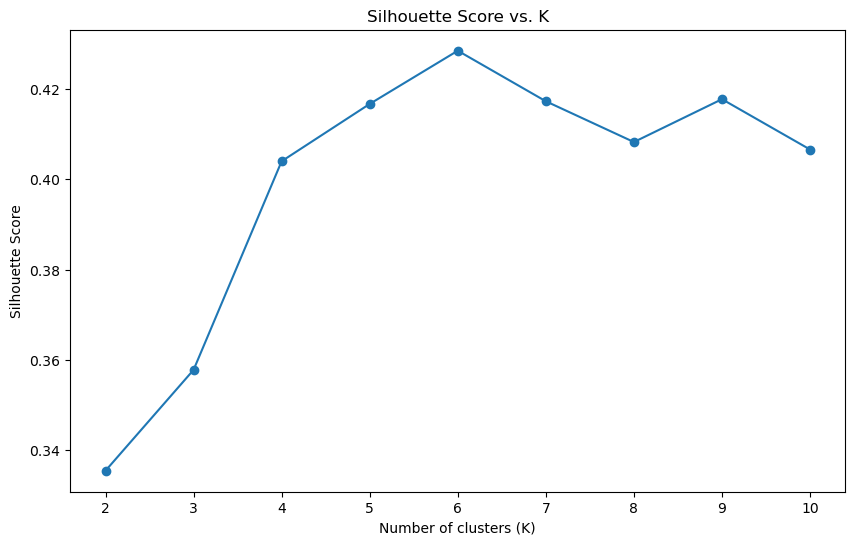

In [55]:

sil_scores = []
sil_k_values = range(2, 11)
for k in sil_k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(10, 6))
plt.plot(sil_k_values, sil_scores, marker='o')
plt.title('Silhouette Score vs. K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(sil_k_values)
plt.show()


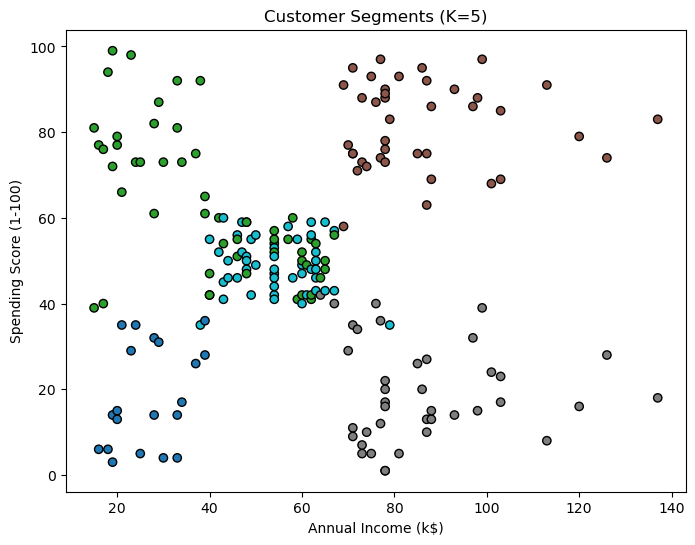

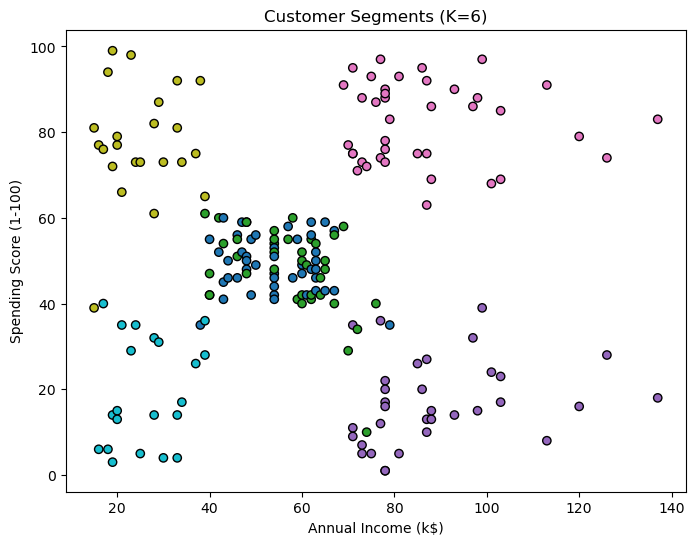

In [56]:
for k in [5, 6]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    plt.figure(figsize=(8, 6))
    plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=labels, cmap='tab10', edgecolor='k')
    plt.xlabel('Annual Income (k$)')
    plt.ylabel('Spending Score (1-100)')
    plt.title(f'Customer Segments (K={k})')
    plt.show()

## Choosing K: 5 vs. 6

Silhouette peaks at K=6 (0.43), just ahead of K=5 (0.417). Visualizing
both resolves the tie: K=6's four outer clusters are identical to
K=5's, the only difference is the average income / average spending
group splitting into two. That split cuts through a single, continuous
cloud of points with no visible internal structure, an arbitrary
division rather than a genuine new segment.

K=5 is chosen: a marginally lower silhouette score, but five
cleanly separated, interpretable customer groups rather than one
real group split in two for a small numerical gain.

In [57]:
km_final = KMeans(n_clusters=5, n_init=10, random_state=42)
df['Cluster'] = km_final.fit_predict(X_scaled)
print(df['Cluster'].value_counts().sort_index())

Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64


In [58]:
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(cluster_profile.round(1))

          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        46.2                26.8                    18.4
1        25.2                41.1                    62.2
2        32.9                86.1                    81.5
3        39.9                86.1                    19.4
4        55.6                54.4                    48.9


In [59]:
print(pd.crosstab(df['Cluster'], df['Genre']))

Genre    Female  Male
Cluster              
0            12     8
1            32    22
2            22    18
3            19    20
4            27    20


## Segment Profiles and Names

| Segment | Age | Income (k$) | Spending Score | Size | Name |
|---|---|---|---|---|---|
| 0 | 46.2 | 26.8 | 18.4 | 20 | Budget-Conscious |
| 1 | 25.2 | 41.1 | 62.2 | 54 | Trend Spenders |
| 2 | 32.9 | 86.1 | 81.5 | 40 | High-Value Customers |
| 3 | 39.9 | 86.1 | 19.4 | 39 | Dormant High-Value |
| 4 | 55.6 | 54.4 | 48.9 | 47 | Average Customers |

Gender distribution is close to the overall dataset split (56% F / 44%
M) in every segment, with no cluster skewing meaningfully by gender.
Segmentation here is driven by age, income, and spending behavior, not
gender.

- **Budget-Conscious** - spending matches limited income; a
  deliberate, careful pattern, not a priority for spend-focused
  campaigns.
- **Trend Spenders** - spending outpaces income, likely driven by
  lifestyle and trends rather than wealth. The largest segment.
- **High-Value Customers** - high income and high spending together,
  and notably younger than the dataset average. The most valuable
  segment.
- **Dormant High-Value** - high income, but spending well below what
  that income could support. Money is there; engagement isn't.
- **Average Customers** - no extreme in income or spending, and the
  oldest segment on average. The steady middle of the customer base.

## Business Recommendation

Five customer segments emerged from this analysis, each with a
genuinely different relationship to the mall. Treating them the same
way, the same discounts, the same campaigns, would waste budget on
customers who don't need it and miss the ones who do.

**High-Value Customers should be retained, not discounted.** They
already spend the most and can afford to keep doing it. The real risk
isn't that they're not spending enough, it's that a competitor offers
them something better and they leave. Early access to premium product
lines, a loyalty program, and genuinely personalized service protect
this relationship without training the group to expect price cuts they
don't need.

**Trend Spenders are the largest group, and their spending follows
trends, not income.** At mid income levels but spending close to what
the top segment spends, these customers are buying into lifestyle and
relevance, not simply what they can afford. Faster turnover of
seasonal stock and trend led promotion will move this group more than
any price incentive would, and because it's the biggest segment, even
a modest lift here adds up.

**Dormant High-Value customers have the money, but something isn't
bringing them in.** They earn exactly what High-Value Customers earn,
yet spend a fraction of it, and they're noticeably older than that
top spending group. The right next step is to ask them directly,
through a short survey or direct outreach, what would bring them back
rather than guessing at the reason. What they say should shape product
and service decisions for this segment, which likely needs a different
fit than the younger High-Value group.

**Budget-Conscious customers respond to price, because price is their
real constraint.** Their spending already tracks closely with a
limited income, so discounts on everyday essentials are the one lever
genuinely suited to this group.

**Average Customers are comfortable, not price sensitive, they're
just not spending much.** This is the oldest segment in the dataset,
with income and spending that sit in the middle, showing no sign that
cost is holding them back. What's more likely to bring them in is
comfort: better seating, easier navigation, and products suited to an
older shopper, not another discount they don't need.

Put plainly: discount the segment that needs it, retain the segment
that's already valuable, chase the trend for the group chasing trends,
ask the group with money that isn't spending it what they actually
want, and make the mall more comfortable for the customers who are
simply older and unhurried.

## Limitations

There are no true customer labels to validate this segmentation
against, only internal checks: the elbow and silhouette scores, and
whether the resulting segments make business sense on inspection.

The choice of K itself involved judgment, not just a formula. Elbow
and silhouette pointed to slightly different answers, and K=5 was
chosen over K=6 because the extra cluster split one coherent group in
two without revealing anything new, not because a score forced the
decision.

These segments also reflect a single snapshot of customer behavior,
not how it changes over time. A customer's spending pattern today
doesn't guarantee the same pattern next year, and the clusters would
need to be rebuilt periodically as the underlying customer base shifts.

Finally, segment sizes range from 20 to 54 customers out of 200 total.
The smallest segments, Budget-Conscious and Dormant High-Value, carry
less statistical weight than the larger ones, and any conclusions
about them should be treated as directional rather than precise.